# Chapter 59 — Softmax Over Attention Scores

## Learning goals

By the end of this chapter, you should be able to:

- Explain why raw attention scores are not attention weights.

- Apply a causal mask before softmax.

- Compute a numerically stable softmax for one row.

- Apply softmax over source positions for an entire score table.

- Verify that every attention row sums to `1` and every future position has weight `0`.

- Explain why the softmax dimension encodes the meaning of the table.

- Distinguish attention weights over positions from vocabulary probabilities over tokens.

- Describe how score scale changes the sharpness of a softmax distribution.

- Extend the same operation to batched attention score tables.


## From scores to weights

Chapter 57 constructed attention score tables from query-key dot products.

Chapter 58 used a causal mask to replace illegal future scores with negative infinity.

This chapter completes the next step:

```text
raw scores → causal mask → row-wise softmax → attention weights
```

Each row belongs to one **receiving position**, the position doing the looking.

Each column identifies one **source position**, a position that may provide information.

Softmax converts each row into an **attention distribution**, a probability distribution over its allowed source positions.

> The softmax is over positions in the context, not over tokens in the vocabulary.


## Raw and masked scores

We continue with the sequence and toy score table from Chapter 58 so that only the new softmax step changes.

The scores are hand-written teaching values rather than outputs from learned query and key projections.

The Boolean causal mask is `True` on and below the diagonal, where attention is allowed.


In [1]:
import torch

device = "cpu"
tokens = ["the", "cat", "sat"]
context_length = len(tokens)

attention_scores = torch.tensor(
    [
        [2.0, 5.0, 1.0],
        [0.5, 1.5, 4.0],
        [1.0, 2.0, 3.0],
    ],
    dtype=torch.float32,
    device=device,
)

causal_mask = torch.tril(
    torch.ones(
        context_length,
        context_length,
        dtype=torch.bool,
        device=device,
    )
)

masked_attention_scores = attention_scores.masked_fill(
    ~causal_mask,
    float("-inf"),
)

print("device:", device)
print("tokens:", tokens)
print("attention_scores.shape:", attention_scores.shape)
print("causal_mask:")
print(causal_mask.to(dtype=torch.int32))
print("masked_attention_scores:")
print(masked_attention_scores)

device: cpu
tokens: ['the', 'cat', 'sat']
attention_scores.shape: torch.Size([3, 3])
causal_mask:
tensor([[1, 0, 0],
        [1, 1, 0],
        [1, 1, 1]], dtype=torch.int32)
masked_attention_scores:
tensor([[2.0000,   -inf,   -inf],
        [0.5000, 1.5000,   -inf],
        [1.0000, 2.0000, 3.0000]])


The score table and mask both have shape `[context length, context length]`.

The mask leaves each position's own score and all earlier scores unchanged.

It replaces future scores above the diagonal with `-inf`, including the high score for `"cat"` looking at future token `"sat"`.


A labeled table makes the row and column roles explicit.


In [2]:
def print_tensor_table(
    table: torch.Tensor,
    labels: list[str],
    title: str,
) -> None:
    if table.shape != (len(labels), len(labels)):
        raise ValueError("table must have one row and column per label.")

    print(title)
    print("-" * len(title))

    header = "receiver \\ source".rjust(20)
    for label in labels:
        header += f" | {label:>8}"

    print(header)
    print("-" * len(header))

    for receiving_position, receiving_label in enumerate(labels):
        row_text = f"{receiving_label:>20}"
        for source_position in range(len(labels)):
            value = table[receiving_position, source_position].item()
            row_text += f" | {value:>8.3f}"
        print(row_text)


print_tensor_table(attention_scores, tokens, "Raw attention scores")
print()
print_tensor_table(masked_attention_scores, tokens, "Masked attention scores")

Raw attention scores
--------------------
   receiver \ source |      the |      cat |      sat
-----------------------------------------------------
                 the |    2.000 |    5.000 |    1.000
                 cat |    0.500 |    1.500 |    4.000
                 sat |    1.000 |    2.000 |    3.000

Masked attention scores
-----------------------
   receiver \ source |      the |      cat |      sat
-----------------------------------------------------
                 the |    2.000 |     -inf |     -inf
                 cat |    0.500 |    1.500 |     -inf
                 sat |    1.000 |    2.000 |    3.000


## One row under a microscope

The `"cat"` row demonstrates exactly how masked scores become weights.

Its raw scores are `[0.5, 1.5, 4.0]`, but the score `4.0` belongs to the future position `"sat"`.

After masking, softmax operates on `[0.5, 1.5, -inf]`.

A numerically stable softmax subtracts the largest finite score before exponentiating.

Subtracting one shared constant does not change the resulting probabilities, but it prevents unnecessarily large exponentials.


In [3]:
def stable_softmax_steps(scores: torch.Tensor) -> dict[str, torch.Tensor]:
    if scores.ndim != 1:
        raise ValueError("scores must be one-dimensional.")

    if not torch.is_floating_point(scores):
        raise TypeError("scores must use a floating-point dtype.")

    if torch.any(torch.isnan(scores)) or torch.any(scores == float("inf")):
        raise ValueError("scores cannot contain NaN or positive infinity.")

    finite_scores = scores[torch.isfinite(scores)]
    if finite_scores.numel() == 0:
        raise ValueError("at least one score must be finite.")

    shifted_scores = scores - finite_scores.max()
    exponentials = torch.exp(shifted_scores)
    denominator = exponentials.sum()
    probabilities = exponentials / denominator

    return {
        "shifted_scores": shifted_scores,
        "exponentials": exponentials,
        "denominator": denominator,
        "probabilities": probabilities,
    }


cat_position = tokens.index("cat")
raw_scores_for_cat = attention_scores[cat_position]
masked_scores_for_cat = masked_attention_scores[cat_position]
softmax_steps_for_cat = stable_softmax_steps(masked_scores_for_cat)
torch_weights_for_cat = torch.softmax(masked_scores_for_cat, dim=0)

print("raw scores:", raw_scores_for_cat)
print("masked scores:", masked_scores_for_cat)
print("shifted scores:", softmax_steps_for_cat["shifted_scores"])
print("exponentials:", softmax_steps_for_cat["exponentials"])
print("denominator:", softmax_steps_for_cat["denominator"])
print("manual weights:", softmax_steps_for_cat["probabilities"])
print("torch weights:", torch_weights_for_cat)
print("row sum:", torch_weights_for_cat.sum())
print(
    "manual and torch results match:",
    torch.allclose(softmax_steps_for_cat["probabilities"], torch_weights_for_cat),
)

raw scores: tensor([0.5000, 1.5000, 4.0000])
masked scores: tensor([0.5000, 1.5000,   -inf])
shifted scores: tensor([-1.,  0., -inf])
exponentials: tensor([0.3679, 1.0000, 0.0000])
denominator: tensor(1.3679)
manual weights: tensor([0.2689, 0.7311, 0.0000])
torch weights: tensor([0.2689, 0.7311, 0.0000])
row sum: tensor(1.)
manual and torch results match: True


The shifted score for `"sat"` remains `-inf`, so its exponential and attention weight are exactly `0`.

The two allowed weights are nonnegative and sum to `1`.

A row with every score masked would have no valid probability distribution, which is why the causal mask keeps the diagonal and guarantees at least one finite score per row.


This bar chart shows the attention distribution for the receiving position `"cat"`.


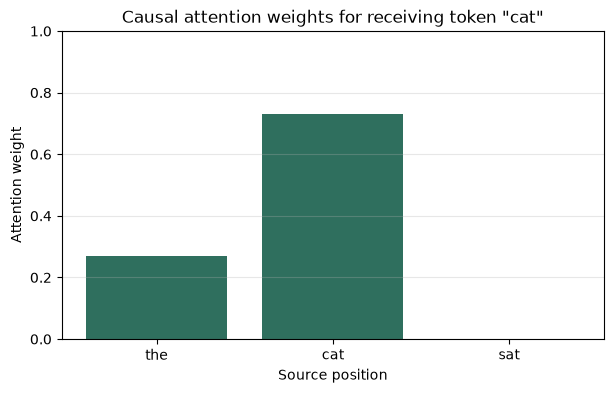

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.bar(tokens, torch_weights_for_cat.detach().tolist(), color="#2f6f5e")
plt.xlabel("Source position")
plt.ylabel("Attention weight")
plt.title('Causal attention weights for receiving token "cat"')
plt.ylim(0.0, 1.0)
plt.grid(axis="y", alpha=0.3)
plt.show()

The largest raw score belonged to the forbidden future position, yet masking gives that position no probability mass.

Softmax redistributes all probability across the two allowed source positions.


## Row-wise softmax for the full table

Applying `torch.softmax` over the last dimension performs the same normalization separately for every receiving position.

For this two-dimensional table, `dim=-1` and `dim=1` both refer to the source-position columns.


In [5]:
attention_weights = torch.softmax(masked_attention_scores, dim=-1)
future_attention_weights = attention_weights[~causal_mask]

print_tensor_table(attention_weights, tokens, "Causal attention weights")
print()
print("attention_weights.shape:", attention_weights.shape)
print("row sums:", attention_weights.sum(dim=-1))
print("future weights:", future_attention_weights)
print(
    "all future weights are zero:",
    torch.all(future_attention_weights == 0.0).item(),
)

Causal attention weights
------------------------
   receiver \ source |      the |      cat |      sat
-----------------------------------------------------
                 the |    1.000 |    0.000 |    0.000
                 cat |    0.269 |    0.731 |    0.000
                 sat |    0.090 |    0.245 |    0.665

attention_weights.shape: torch.Size([3, 3])
row sums: tensor([1., 1., 1.])
future weights: tensor([0., 0., 0.])
all future weights are zero: True


Softmax changes the values but not the shape: both scores and weights have shape `[receiving positions, source positions]`.

Every row sums to `1`, while every entry above the diagonal is `0`.

The rows are mathematical probability distributions over source positions, although an individual attention weight should not automatically be treated as a complete explanation of a model's behavior.


## The softmax dimension carries meaning

The correct last-dimension softmax answers the intended question for each row: how should this receiving position distribute weight across source positions?

A softmax over `dim=0` instead normalizes each column across receiving positions.

That operation returns the same shape and plausible-looking numbers, which makes the axis error easy to miss.


In [6]:
wrong_columnwise_weights = torch.softmax(masked_attention_scores, dim=0)

print_tensor_table(
    wrong_columnwise_weights,
    tokens,
    "Wrong: softmax across receiving positions",
)
print()
print("column sums:", wrong_columnwise_weights.sum(dim=0))
print("row sums:", wrong_columnwise_weights.sum(dim=1))

Wrong: softmax across receiving positions
-----------------------------------------
   receiver \ source |      the |      cat |      sat
-----------------------------------------------------
                 the |    0.629 |    0.000 |    0.000
                 cat |    0.140 |    0.378 |    0.000
                 sat |    0.231 |    0.622 |    1.000

column sums: tensor([1.0000, 1.0000, 1.0000])
row sums: tensor([0.6285, 0.5178, 1.8537])


The columns now sum to `1`, but the rows do not.

Ordinary attention needs one distribution per receiving position, so its rows must sum to `1`.


## Attention and vocabulary distributions

Attention weights and vocabulary probabilities can both be nonnegative distributions that sum to `1`, but their sample spaces differ.

An attention distribution assigns probability to source positions already present in the context.

A vocabulary distribution assigns probability to token types that could be predicted next.


In [7]:
possible_next_tokens = ["sat", "ran", "slept", "."]
fake_vocabulary_probabilities = torch.tensor(
    [0.7, 0.1, 0.1, 0.1],
    dtype=torch.float32,
    device=device,
)

print("Attention distribution for receiving position 'cat':")
for source_token, weight in zip(tokens, attention_weights[cat_position], strict=True):
    print(f"  source position {source_token!r}: {weight.item():.6f}")

print("\nToy vocabulary distribution:")
for token, probability in zip(
    possible_next_tokens, fake_vocabulary_probabilities, strict=True
):
    print(f"  possible next token {token!r}: {probability.item():.6f}")

Attention distribution for receiving position 'cat':
  source position 'the': 0.268941
  source position 'cat': 0.731059
  source position 'sat': 0.000000

Toy vocabulary distribution:
  possible next token 'sat': 0.700000
  possible next token 'ran': 0.100000
  possible next token 'slept': 0.100000
  possible next token '.': 0.100000


The first distribution controls where the attention operation gathers information from.

The second toy distribution represents a later prediction choice and is included only to clarify the difference in domains.


## Score scale controls concentration

Softmax preserves score order but reacts strongly to differences in score magnitude.

Multiplying a row by `10` makes the resulting distribution much more concentrated on its largest score.


In [8]:
moderate_scores = torch.tensor(
    [1.0, 0.0, -1.0],
    dtype=torch.float32,
    device=device,
)
large_scores = 10.0 * moderate_scores

moderate_weights = torch.softmax(moderate_scores, dim=0)
large_weights = torch.softmax(large_scores, dim=0)

print("moderate scores:", moderate_scores)
print("moderate weights:", moderate_weights)
print("large scores:", large_scores)
print("large weights:", large_weights)

moderate scores: tensor([ 1.,  0., -1.])
moderate weights: tensor([0.6652, 0.2447, 0.0900])
large scores: tensor([ 10.,   0., -10.])
large weights: tensor([9.9995e-01, 4.5398e-05, 2.0611e-09])


The largest position receives much more probability in the large-score row.

This sensitivity motivates scaled dot-product attention, which controls the typical size of query-key scores before softmax.


## Batched score tables

During training, attention scores usually include a batch dimension.

The last dimension still indexes source positions, so `dim=-1` keeps the correct meaning without depending on the number of leading dimensions.

A mask with shape `[context length, context length]` broadcasts across the batch.


In [9]:
batched_attention_scores = torch.stack(
    [
        attention_scores,
        attention_scores + 0.25,
    ],
    dim=0,
)

batched_masked_scores = batched_attention_scores.masked_fill(
    ~causal_mask,
    float("-inf"),
)
batched_attention_weights = torch.softmax(batched_masked_scores, dim=-1)
expanded_future_mask = (~causal_mask).expand_as(batched_attention_weights)
batched_future_weights = batched_attention_weights[expanded_future_mask]

print("batched scores shape:", batched_attention_scores.shape)
print("mask shape:", causal_mask.shape)
print("batched weights shape:", batched_attention_weights.shape)
print("row sums:")
print(batched_attention_weights.sum(dim=-1))
print("all future weights are zero:", end=" ")
print(torch.all(batched_future_weights == 0.0).item())

batched scores shape: torch.Size([2, 3, 3])
mask shape: torch.Size([3, 3])
batched weights shape: torch.Size([2, 3, 3])
row sums:
tensor([[1., 1., 1.],
        [1., 1., 1.]])
all future weights are zero: True


The batched weights have shape `[batch size, receiving positions, source positions]`.

Every row in every batch item sums to `1`, and broadcasting applies the same positional rule to both sequences.

Adding the same constant to every score in the second batch item leaves its softmax weights unchanged, another consequence of softmax's shift invariance.


## Common mistakes

- **Applying softmax before masking:** masking probabilities afterward leaves rows improperly normalized unless they are normalized again.

- **Replacing future scores with zero:** a zero score still receives positive softmax weight when other finite scores exist.

- **Using the wrong dimension:** column-wise normalization answers a different question even though the output shape looks correct.

- **Masking every entry in a row:** softmax cannot produce a valid distribution when no source position is allowed.

- **Confusing domains:** attention weights range over source positions, while output probabilities range over vocabulary tokens.

- **Treating weights as complete explanations:** attention weights show one model operation, not every pathway that influences a prediction.


## Takeaways

- Raw query-key scores become causal attention weights only after future positions are masked and softmax is applied.

- Softmax runs across source-position columns so that each receiving-position row sums to `1`.

- Negative infinity gives a masked future position an exact weight of `0`.

- Scores and weights share the same table shape, but scores are unrestricted matching values and weights are normalized distributions.

- Attention weights are probabilities over positions, not vocabulary tokens.

- Large score differences create sharper distributions, motivating attention-score scaling.


## What comes next

The next chapter assembles one complete causal self-attention head.

It will project input vectors into queries, keys, and values, scale and mask the query-key scores, apply the row-wise softmax developed here, and use the resulting weights to mix value vectors.
